# Lagrangian Coherent Structure (LCS) Map Around the Cabo Verde Region

In [1]:
import math
from datetime import timedelta

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import pandas as pd
from scipy.interpolate import griddata

import parcels
from parcels import StatusCode

## Parameters

In [2]:
lon_min = -29
lon_max = -22.5
lat_min = 14
lat_max = 19.5

refine_lon_fac = 5
refine_lat_fac = 5

reference_time = "2025-08-22"

integration_days = 10
integration_direction = -1

reference_times = pd.date_range(date_start, date_end, freq=date_freq)
reference_seasons = [season_of(t.month) for t in reference_times]

In [3]:
flowfield_env = xr.open_dataset("ssc.nc")
flowfield_env

/home/b/b384140/.conda/envs/parcels/lib/python3.14/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


<xarray.Dataset> Size: 2GB
Dimensions:    (time: 12199, latitude: 85, longitude: 109)
Coordinates:
    depth      float32 4B ...
  * latitude   (latitude) float32 340B 13.0 13.08 13.17 ... 19.83 19.92 20.0
  * longitude  (longitude) float32 436B -29.0 -28.92 -28.83 ... -20.08 -20.0
  * time       (time) datetime64[ns] 98kB 1993-01-01 1993-01-02 ... 2026-05-26
Data variables:
    uo         (time, latitude, longitude) float64 904MB ...
    vo         (time, latitude, longitude) float64 904MB ...
Attributes: (12/25)
    Conventions:               CF-1.4
    bulletin_date:             2021-07-07 00:00:00
    bulletin_type:             operational
    comment:                   CMEMS product
    domain_name:               GL12
    easting:                   longitude
    ...                        ...
    references:                http://www.mercator-ocean.fr
    source:                    MERCATOR GLORYS12V1
    title:                     daily mean fields from Global Ocean Physics An...
    z_max:                     5727.9169921875
    z_min:                     0.49402499198913574
    copernicusmarine_version:  2.4.1

## Boundary Conditions

In [4]:
# TODO: Let's implement with xr.where to be independent of numpy api
flowfield_env["uo"][:, :,  0] = 0.0
flowfield_env["uo"][:, :, -1] = 0.0
flowfield_env["uo"][:,  0, :] = 0.0
flowfield_env["uo"][:, -1, :] = 0.0
flowfield_env["vo"][:, :,  0] = 0.0
flowfield_env["vo"][:, :, -1] = 0.0
flowfield_env["vo"][:,  0, :] = 0.0
flowfield_env["vo"][:, -1, :] = 0.0

In [5]:
ocean_mask = flowfield_env.uo.mean("time").notnull().astype(float)

In [6]:
v_repel = 0.02

mask = ocean_mask.values
nj, ni = mask.shape
u_rep_arr = np.zeros((nj, ni))
v_rep_arr = np.zeros((nj, ni))

for j in range(1, nj - 1):
    for i in range(1, ni - 1):
        if mask[j, i] == 0:
            continue
        if mask[j,   i-1] == 0: u_rep_arr[j, i] += v_repel
        if mask[j,   i+1] == 0: u_rep_arr[j, i] -= v_repel
        if mask[j-1, i  ] == 0: v_rep_arr[j, i] += v_repel
        if mask[j+1, i  ] == 0: v_rep_arr[j, i] -= v_repel

In [7]:
u_repel = xr.DataArray(u_rep_arr, coords=ocean_mask.coords, dims=ocean_mask.dims)
v_repel_field = xr.DataArray(v_rep_arr, coords=ocean_mask.coords, dims=ocean_mask.dims)

In [8]:
flowfield_env["uo"] = flowfield_env.uo + u_repel
flowfield_env["vo"] = flowfield_env.vo + v_repel_field

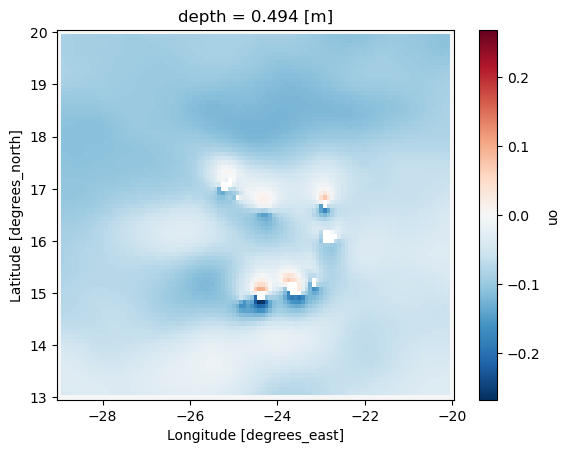

In [9]:
flowfield_env.uo.mean("time").plot()

## Parcels Fieldset

In [10]:
fieldset = parcels.FieldSet.from_xarray_dataset(
    flowfield_env,
    variables={"U": "uo", "V": "vo"},
    dimensions={"lon": "longitude", "lat": "latitude", "time": "time"},
)

## Setting up Particle Triplets

In [11]:
particle_lon = xr.DataArray(
    data=np.linspace(
        flowfield_env.longitude.min().item(),
        flowfield_env.longitude.max().item(),
        refine_lon_fac * flowfield_env.sizes["longitude"] - 1
    ),
    name="plon",
    dims="plon",
)
particle_lat = xr.DataArray(
    data=np.linspace(
        flowfield_env.latitude.min().item(),
        flowfield_env.latitude.max().item(),
        refine_lat_fac * flowfield_env.sizes["latitude"] - 1
    ),
    name="plat",
    dims="plat",
)
particle_lon, particle_lat = xr.broadcast(particle_lon, particle_lat)

In [12]:
eigenvector_plot_count = particle_lon.data.size
eigenvector_plot_count

230656

In [13]:
pset = parcels.ParticleSet.from_list(
    fieldset=fieldset,
    pclass=parcels.JITParticle,
    lon=particle_lon.stack(pid=["plon", "plat"]).load().data,
    lat=particle_lat.stack(pid=["plon", "plat"]).load().data,
    time=np.datetime64(reference_time),
)
print(pset)

<ParticleSet>
    fieldset   :
        <FieldSet>
            fields:
                <Field>
                    name            : 'U'
                    grid            : RectilinearZGrid(lon=array([-29.00, -28.92, -28.83, ..., -20.17, -20.08, -20.00], shape=(109,), dtype=float32), lat=array([ 13.00,  13.08,  13.17, ...,  19.83,  19.92,  20.00], shape=(85,), dtype=float32), time=array([ 0.00,  86400.00,  172800.00, ...,  1053734400.00,  1053820800.00,  1053907200.00], shape=(12199,)), time_origin=1993-01-01T00:00:00.000000000, mesh='spherical')
                    extrapolate time: False
                    time_periodic   : False
                    gridindexingtype: 'nemo'
                    to_write        : False
                <Field>
                    name            : 'V'
                    grid            : RectilinearZGrid(lon=array([-29.00, -28.92, -28.83, ..., -20.17, -20.08, -20.00], shape=(109,), dtype=float32), lat=array([ 13.00,  13.08,  13.17, ...,  19.83,  19.9

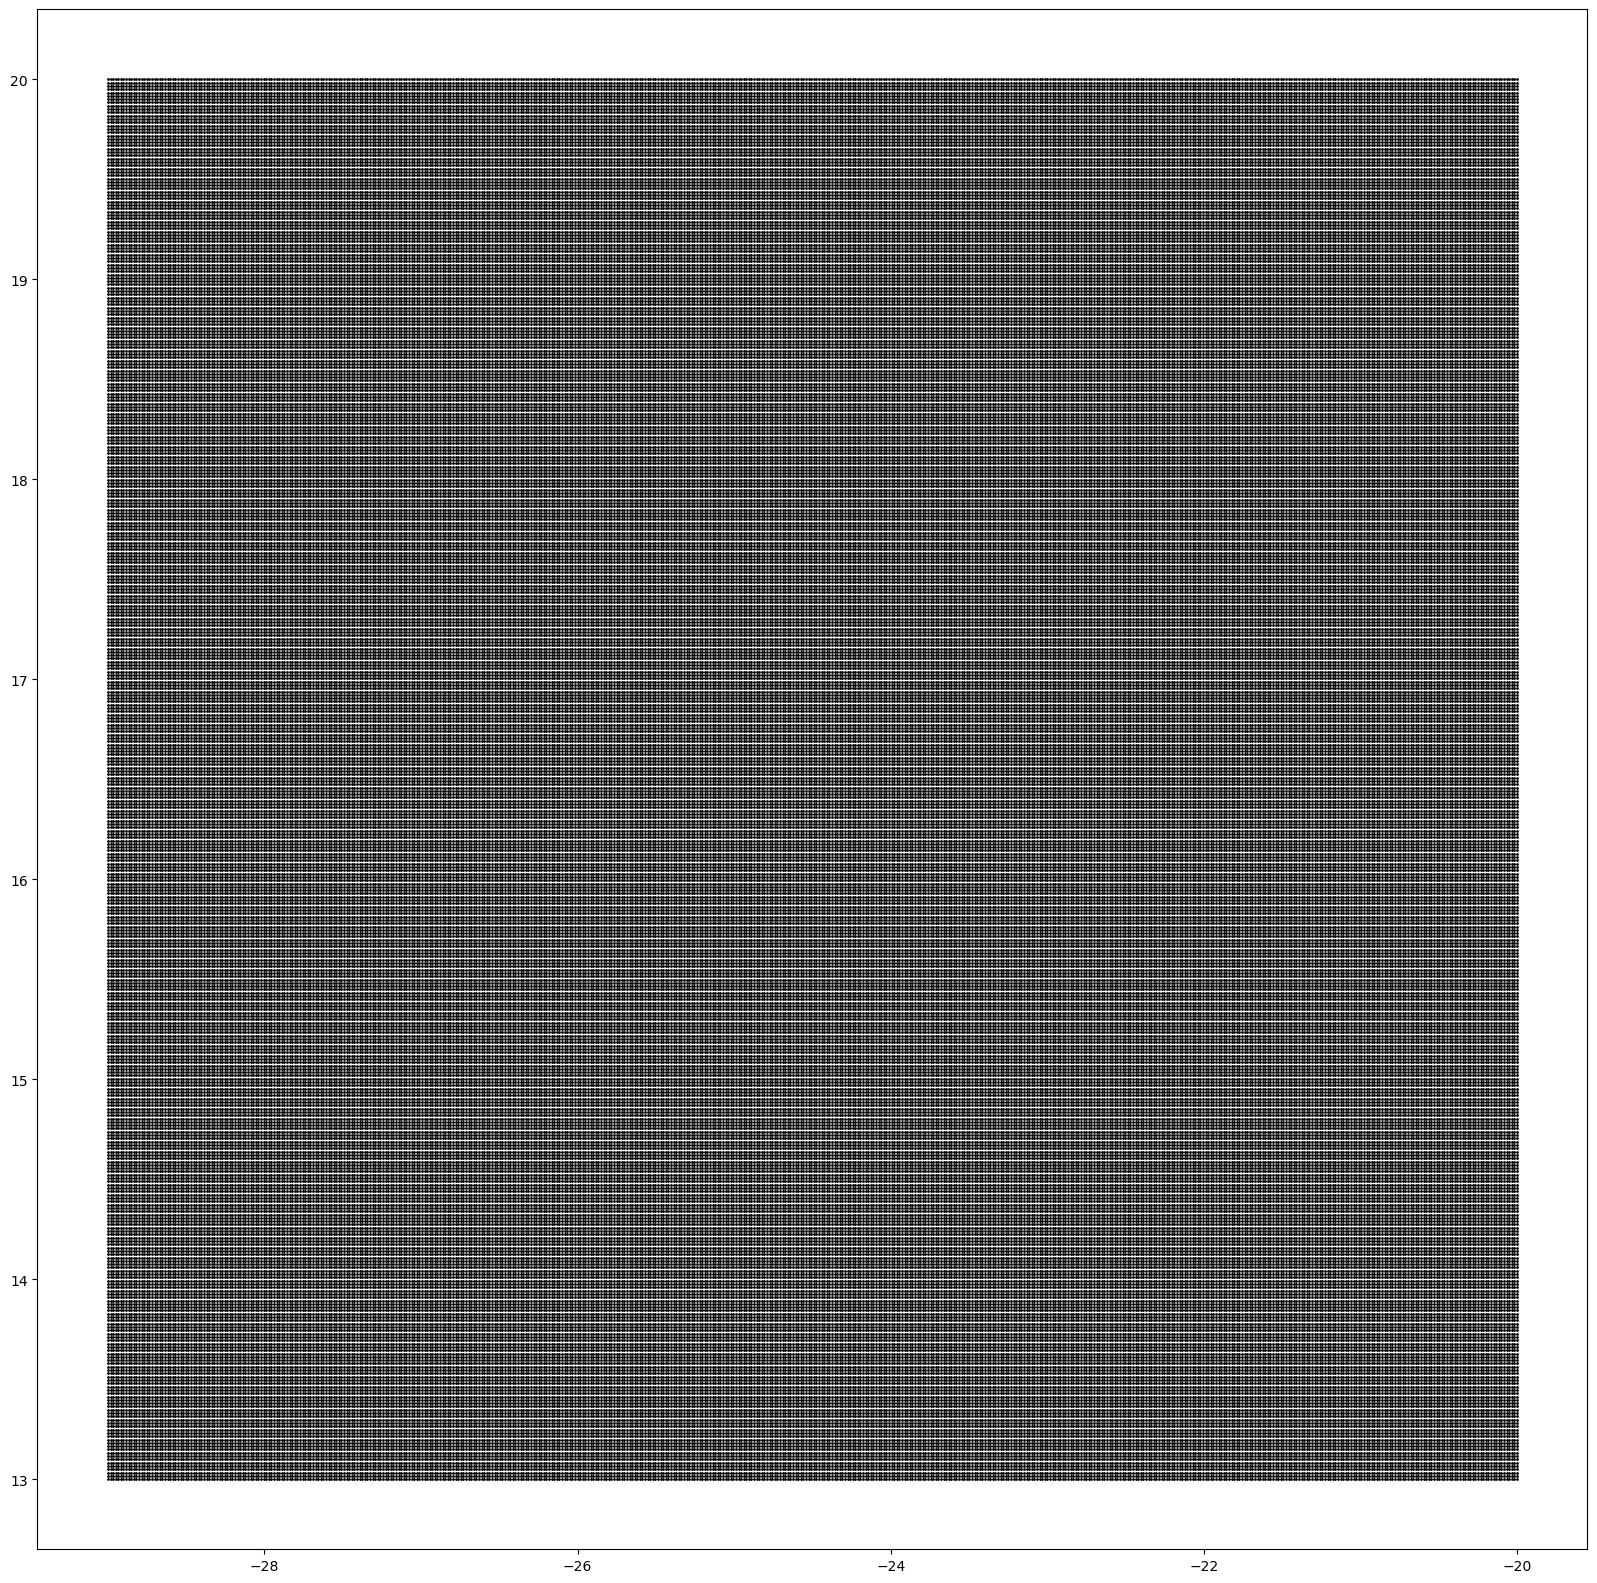

In [14]:
# plt.pcolormesh(fieldset.U.grid.lon, fieldset.U.grid.lat, fieldset.U.data[11, :, :])
# plt.xlabel("longitude")
# plt.ylabel("latitude")
# plt.colorbar()

fig, ax = plt.subplots(1, 1, figsize=(20, 20))
ax.plot(pset.lon, pset.lat, "ko", markersize=1)
plt.show()

## Particle Advection

In [15]:
output_file = pset.ParticleFile(
    name="../data/CV_gridParticles.zarr",
    outputdt=timedelta(hours=1), 
)

In [16]:
def CheckOutOfBounds(particle, fieldset, time):
    if particle.state == StatusCode.ErrorOutOfBounds:
        particle.delete()

def CheckError(particle, fieldset, time):
    if particle.state >= 50:
        particle.delete()

kernels = (
    pset.Kernel(parcels.AdvectionRK4)
    + pset.Kernel(CheckOutOfBounds)
)

pset.execute(
    kernels,
    runtime=timedelta(days=integration_days),
    dt=timedelta(minutes=int(integration_direction * 5)),
    #output_file=output_file,
)

100%|██████████| 864000.0/864000.0 [05:31<00:00, 2603.14it/s]


In [17]:
print(pset)

<ParticleSet>
    fieldset   :
        <FieldSet>
            fields:
                <Field>
                    name            : 'U'
                    grid            : RectilinearZGrid(lon=array([-29.00, -28.92, -28.83, ..., -20.17, -20.08, -20.00], shape=(109,), dtype=float32), lat=array([ 13.00,  13.08,  13.17, ...,  19.83,  19.92,  20.00], shape=(85,), dtype=float32), time=array([ 0.00,  86400.00,  172800.00, ...,  1053734400.00,  1053820800.00,  1053907200.00], shape=(12199,)), time_origin=1993-01-01T00:00:00.000000000, mesh='spherical')
                    extrapolate time: False
                    time_periodic   : False
                    gridindexingtype: 'nemo'
                    to_write        : False
                <Field>
                    name            : 'V'
                    grid            : RectilinearZGrid(lon=array([-29.00, -28.92, -28.83, ..., -20.17, -20.08, -20.00], shape=(109,), dtype=float32), lat=array([ 13.00,  13.08,  13.17, ...,  19.83,  19.9

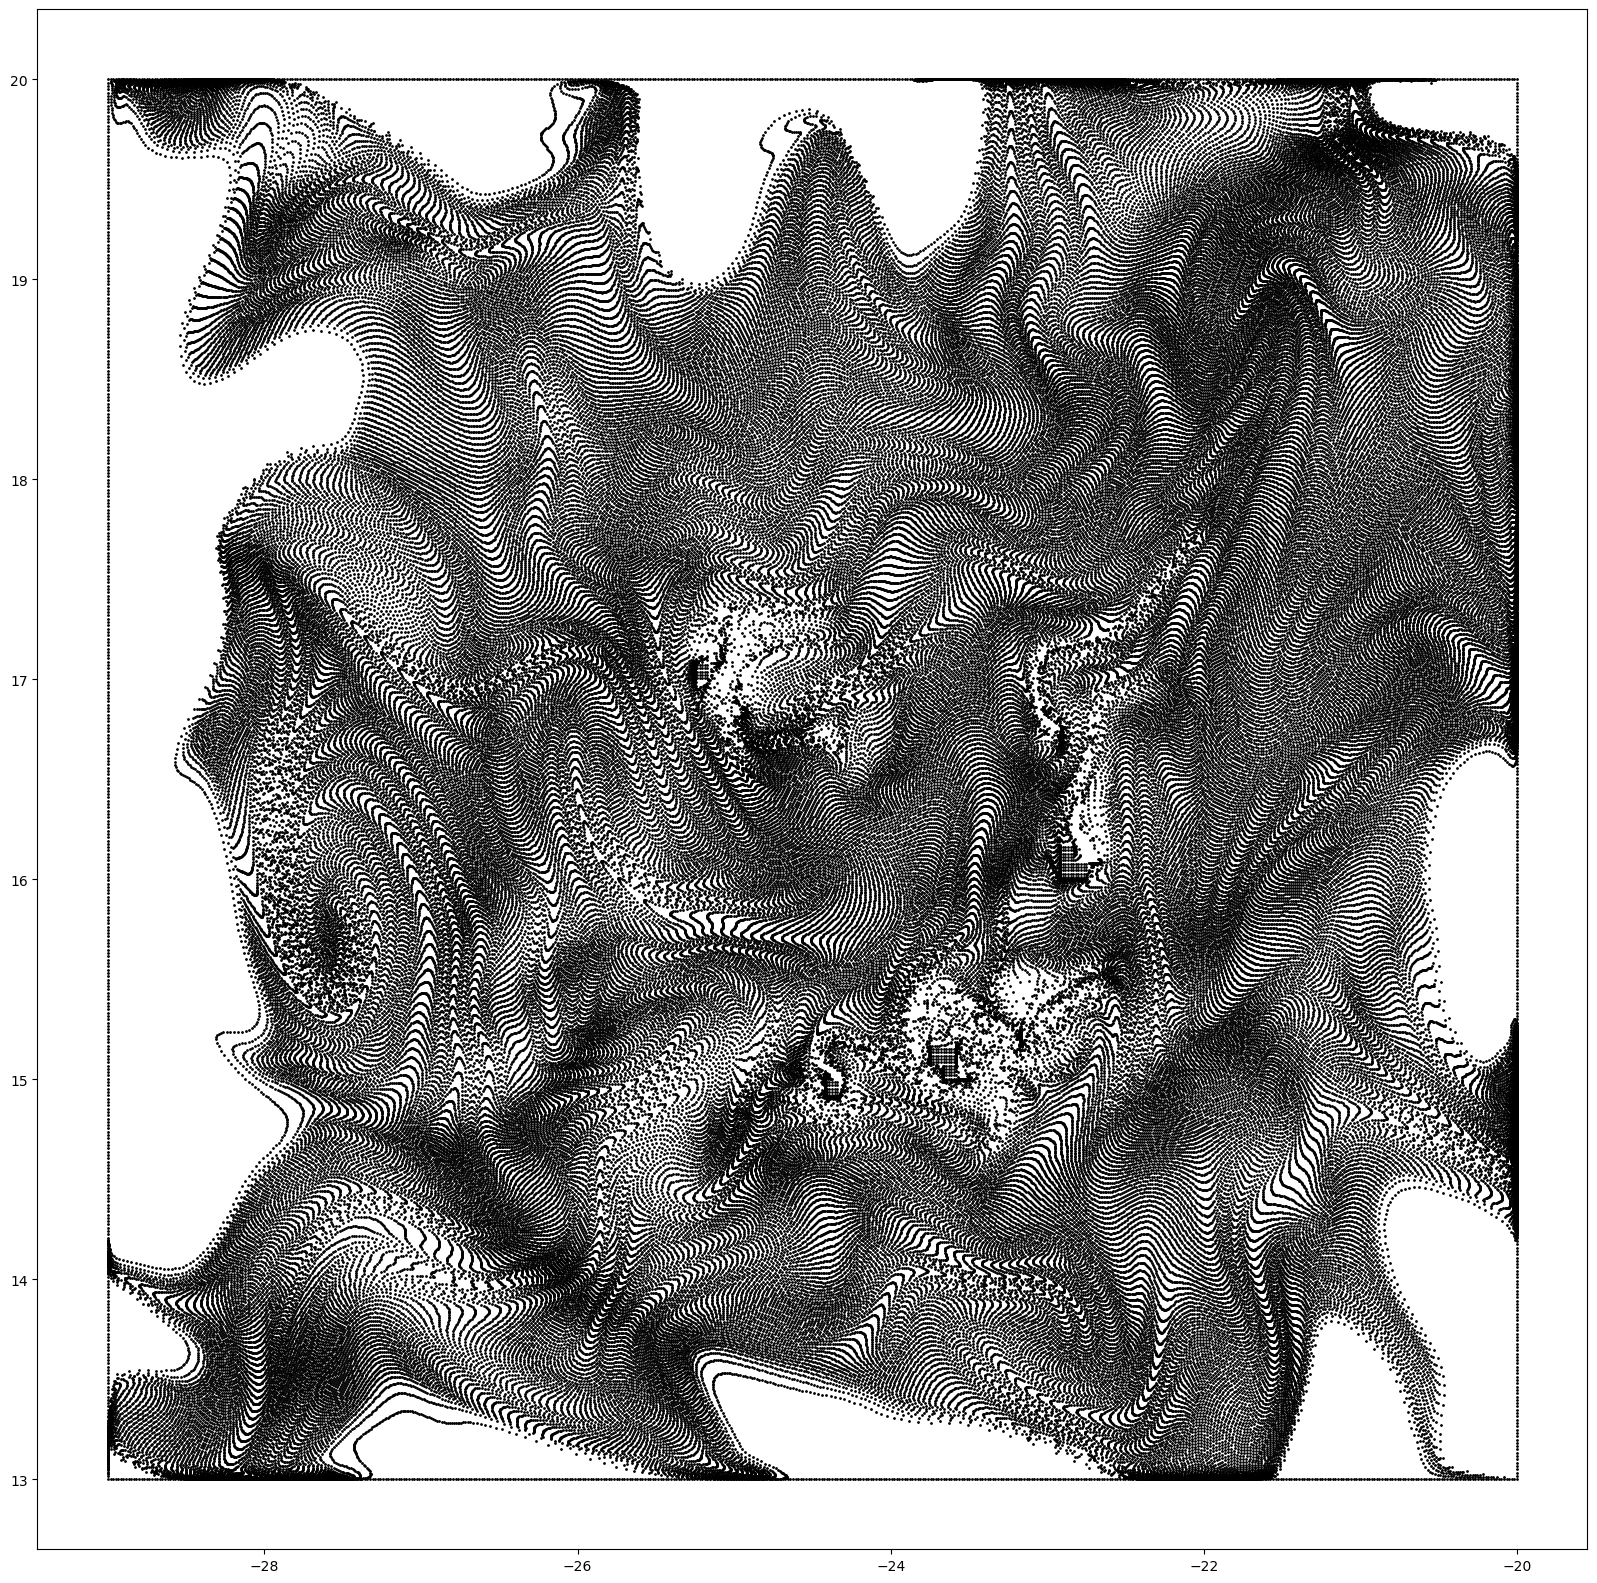

In [18]:
# plt.pcolormesh(fieldset.U.grid.lon, fieldset.U.grid.lat, fieldset.U.data[11, :, :])
# plt.xlabel("longitude")
# plt.ylabel("latitude")
# plt.colorbar()

fig, ax = plt.subplots(1, 1, figsize=(20, 20))
ax.plot(pset.lon, pset.lat, "ko", markersize=1)
plt.show()

## Deformation Gradient Tensor

In [19]:
final_lon = (particle_lon.stack(pid=["plon", "plat"]) * 0 + pset.lon).unstack()
final_lat = (particle_lat.stack(pid=["plon", "plat"]) * 0 + pset.lat).unstack()

In [20]:
final_lon

<xarray.DataArray 'plon' (plon: 544, plat: 424)> Size: 2MB
array([[-29.        , -29.        , -29.        , ..., -29.        ,
        -29.        , -29.        ],
       [-28.98342514, -28.99803734, -28.99958992, ..., -28.97972488,
        -28.98171425, -28.98342514],
       [-28.96685028, -28.99821472, -28.99981117, ..., -28.96074677,
        -28.96375084, -28.96685028],
       ...,
       [-20.03314972, -20.13003159, -20.23920441, ..., -20.77328873,
        -20.67634773, -20.03314972],
       [-20.01657486, -20.0818882 , -20.21538925, ..., -20.74550629,
        -20.5489006 , -20.01657486],
       [-20.        , -20.        , -20.        , ..., -20.        ,
        -20.        , -20.        ]], shape=(544, 424))
Coordinates:
  * plon     (plon) int64 4kB 0 1 2 3 4 5 6 7 ... 537 538 539 540 541 542 543
  * plat     (plat) int64 3kB 0 1 2 3 4 5 6 7 ... 417 418 419 420 421 422 423

In [21]:
dX = (final_lon.shift(plon=-1) - final_lon.shift(plon=1)) * 111e3 * np.cos(np.deg2rad(final_lat))
dx = (particle_lon.shift(plon=-1) - particle_lon.shift(plon=1)) * 111e3 * np.cos(np.deg2rad(particle_lat))

dY = (final_lat.shift(plat=-1) - final_lat.shift(plat=1)) * 111e3
dy = (particle_lat.shift(plat=-1) - particle_lat.shift(plat=1)) * 111e3

In [22]:
F = np.array([
    [(dX/dx).stack(pid=["plon", "plat"]), (dX/dy).stack(pid=["plon", "plat"])],
    [(dY/dx).stack(pid=["plon", "plat"]), (dY/dy).stack(pid=["plon", "plat"])],
])

In [23]:
F.shape

(2, 2, 230656)

## Cauchy-Green Strain Tensor computation

In [24]:
C   = np.einsum("kil,kjl->ijl", F, F) 
print(C.shape)
C_T = np.transpose(C, (2, 0, 1))      
eigenvalues, eigenvectors = np.linalg.eigh(C_T)

(2, 2, 230656)


In [25]:
ev_max = eigenvectors[:, :, -1]

In [26]:
eigenvalues.shape

(230656, 2)

In [27]:
eval_max = eigenvalues[:, -1]

In [28]:
eval_max.shape

(230656,)

## LCS maps

In [29]:
T = integration_days * 24 * 60 * 60

In [30]:
max_eigenvalues = (np.max(eigenvalues, axis=1) + particle_lon.stack(pid=["plon", "plat"]) * 0).rename("lambda_plus").unstack()
max_eigenvalues = max_eigenvalues.assign_coords(
    plon=particle_lon.isel(plat=0, drop=True),
    plat=particle_lat.isel(plon=0, drop=True),
)
max_eigenvalues

<xarray.DataArray 'lambda_plus' (plon: 544, plat: 424)> Size: 2MB
array([[          nan,           nan,           nan, ...,           nan,
                  nan,           nan],
       [          nan,    3.89844485,    2.59111094, ...,    2.9718985 ,
           2.68930438,           nan],
       [          nan,    6.47356879,    3.17832977, ...,    2.44554385,
           2.22323396,           nan],
       ...,
       [          nan,    9.60350829,    4.6152955 , ...,    1.63725157,
          42.88856083,           nan],
       [          nan,   31.19622128,  103.22019487, ..., 1026.32063287,
         785.24070009,           nan],
       [          nan,           nan,           nan, ...,           nan,
                  nan,           nan]], shape=(544, 424))
Coordinates:
  * plon     (plon) float64 4kB -29.0 -28.98 -28.97 ... -20.03 -20.02 -20.0
  * plat     (plat) float64 3kB 13.0 13.02 13.03 13.05 ... 19.97 19.98 20.0

In [31]:
max_eigenvalues.drop_encoding().to_netcdf(f"010_max_eigenvalues_{reference_time}.nc")

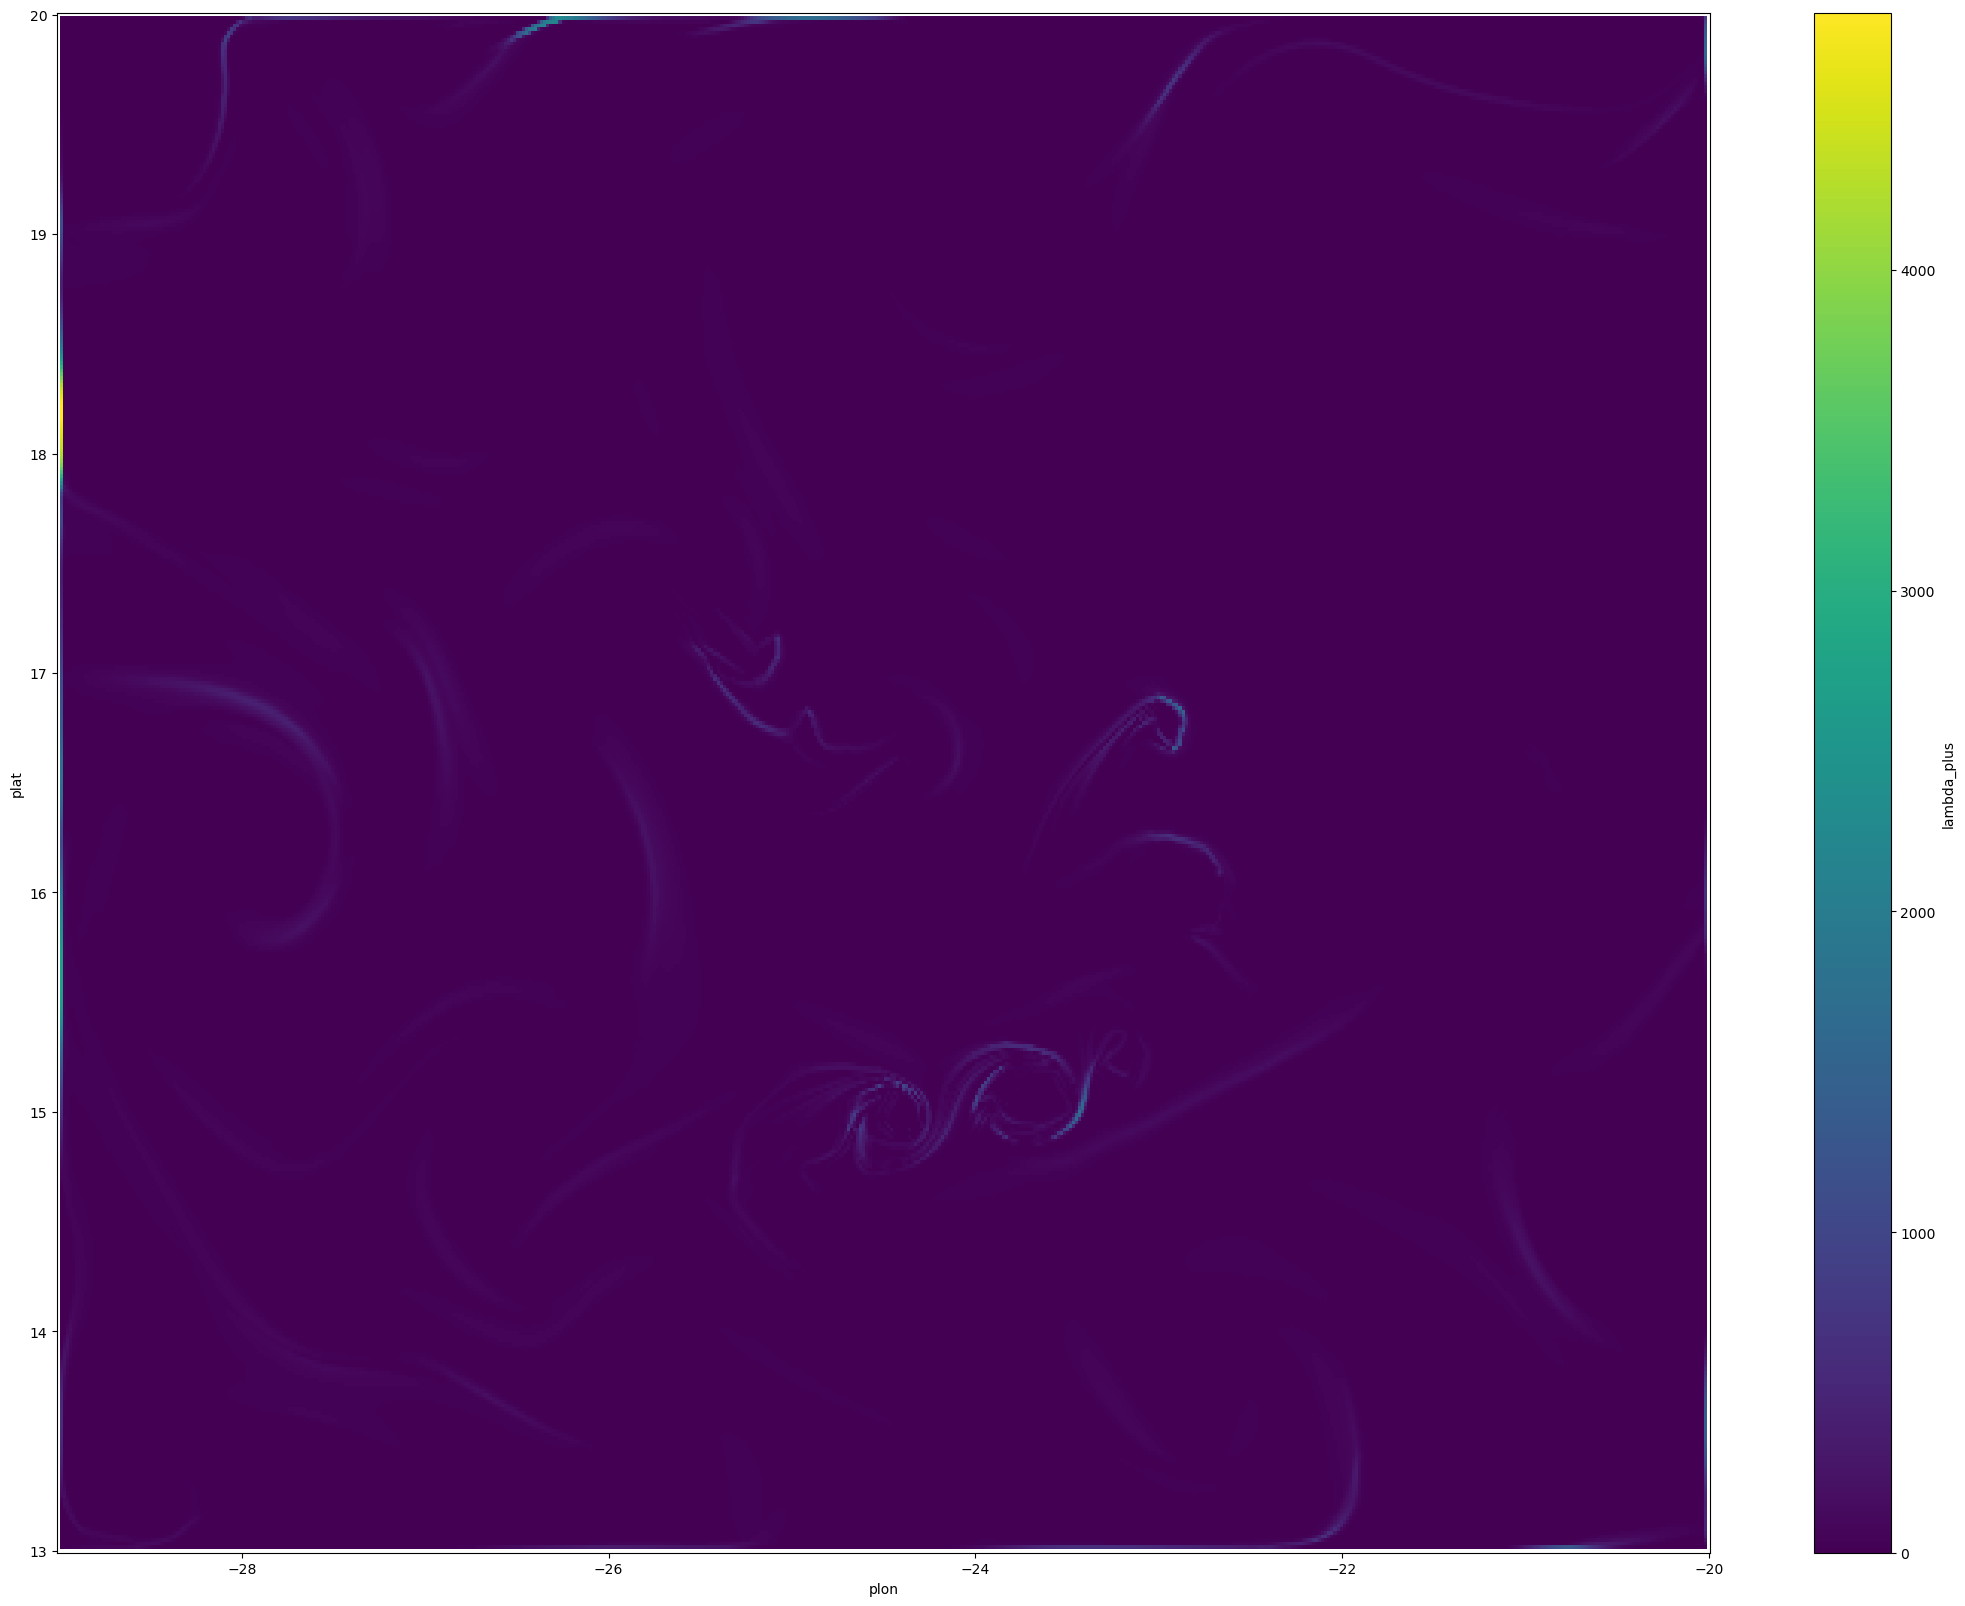

In [32]:
max_eigenvalues.plot(x="plon", y="plat", size=20)

In [33]:
FTLE = (1/(2*T)) * np.log(np.maximum(max_eigenvalues, 1e-10))
FTLE

<xarray.DataArray 'lambda_plus' (plon: 544, plat: 424)> Size: 2MB
array([[           nan,            nan,            nan, ...,
                   nan,            nan,            nan],
       [           nan, 7.87371364e-07, 5.50976110e-07, ...,
        6.30324638e-07, 5.72501485e-07,            nan],
       [           nan, 1.08086085e-06, 6.69187401e-07, ...,
        5.17515932e-07, 4.62362776e-07,            nan],
       ...,
       [           nan, 1.30910213e-06, 8.85055495e-07, ...,
        2.85311902e-07, 2.17511872e-06,            nan],
       [           nan, 1.99091260e-06, 2.68337067e-06, ...,
        4.01257841e-06, 3.85763327e-06,            nan],
       [           nan,            nan,            nan, ...,
                   nan,            nan,            nan]], shape=(544, 424))
Coordinates:
  * plon     (plon) float64 4kB -29.0 -28.98 -28.97 ... -20.03 -20.02 -20.0
  * plat     (plat) float64 3kB 13.0 13.02 13.03 13.05 ... 19.97 19.98 20.0

In [34]:
FTLE.drop_encoding().to_netcdf(f"010_FTLE_{reference_time}.nc")

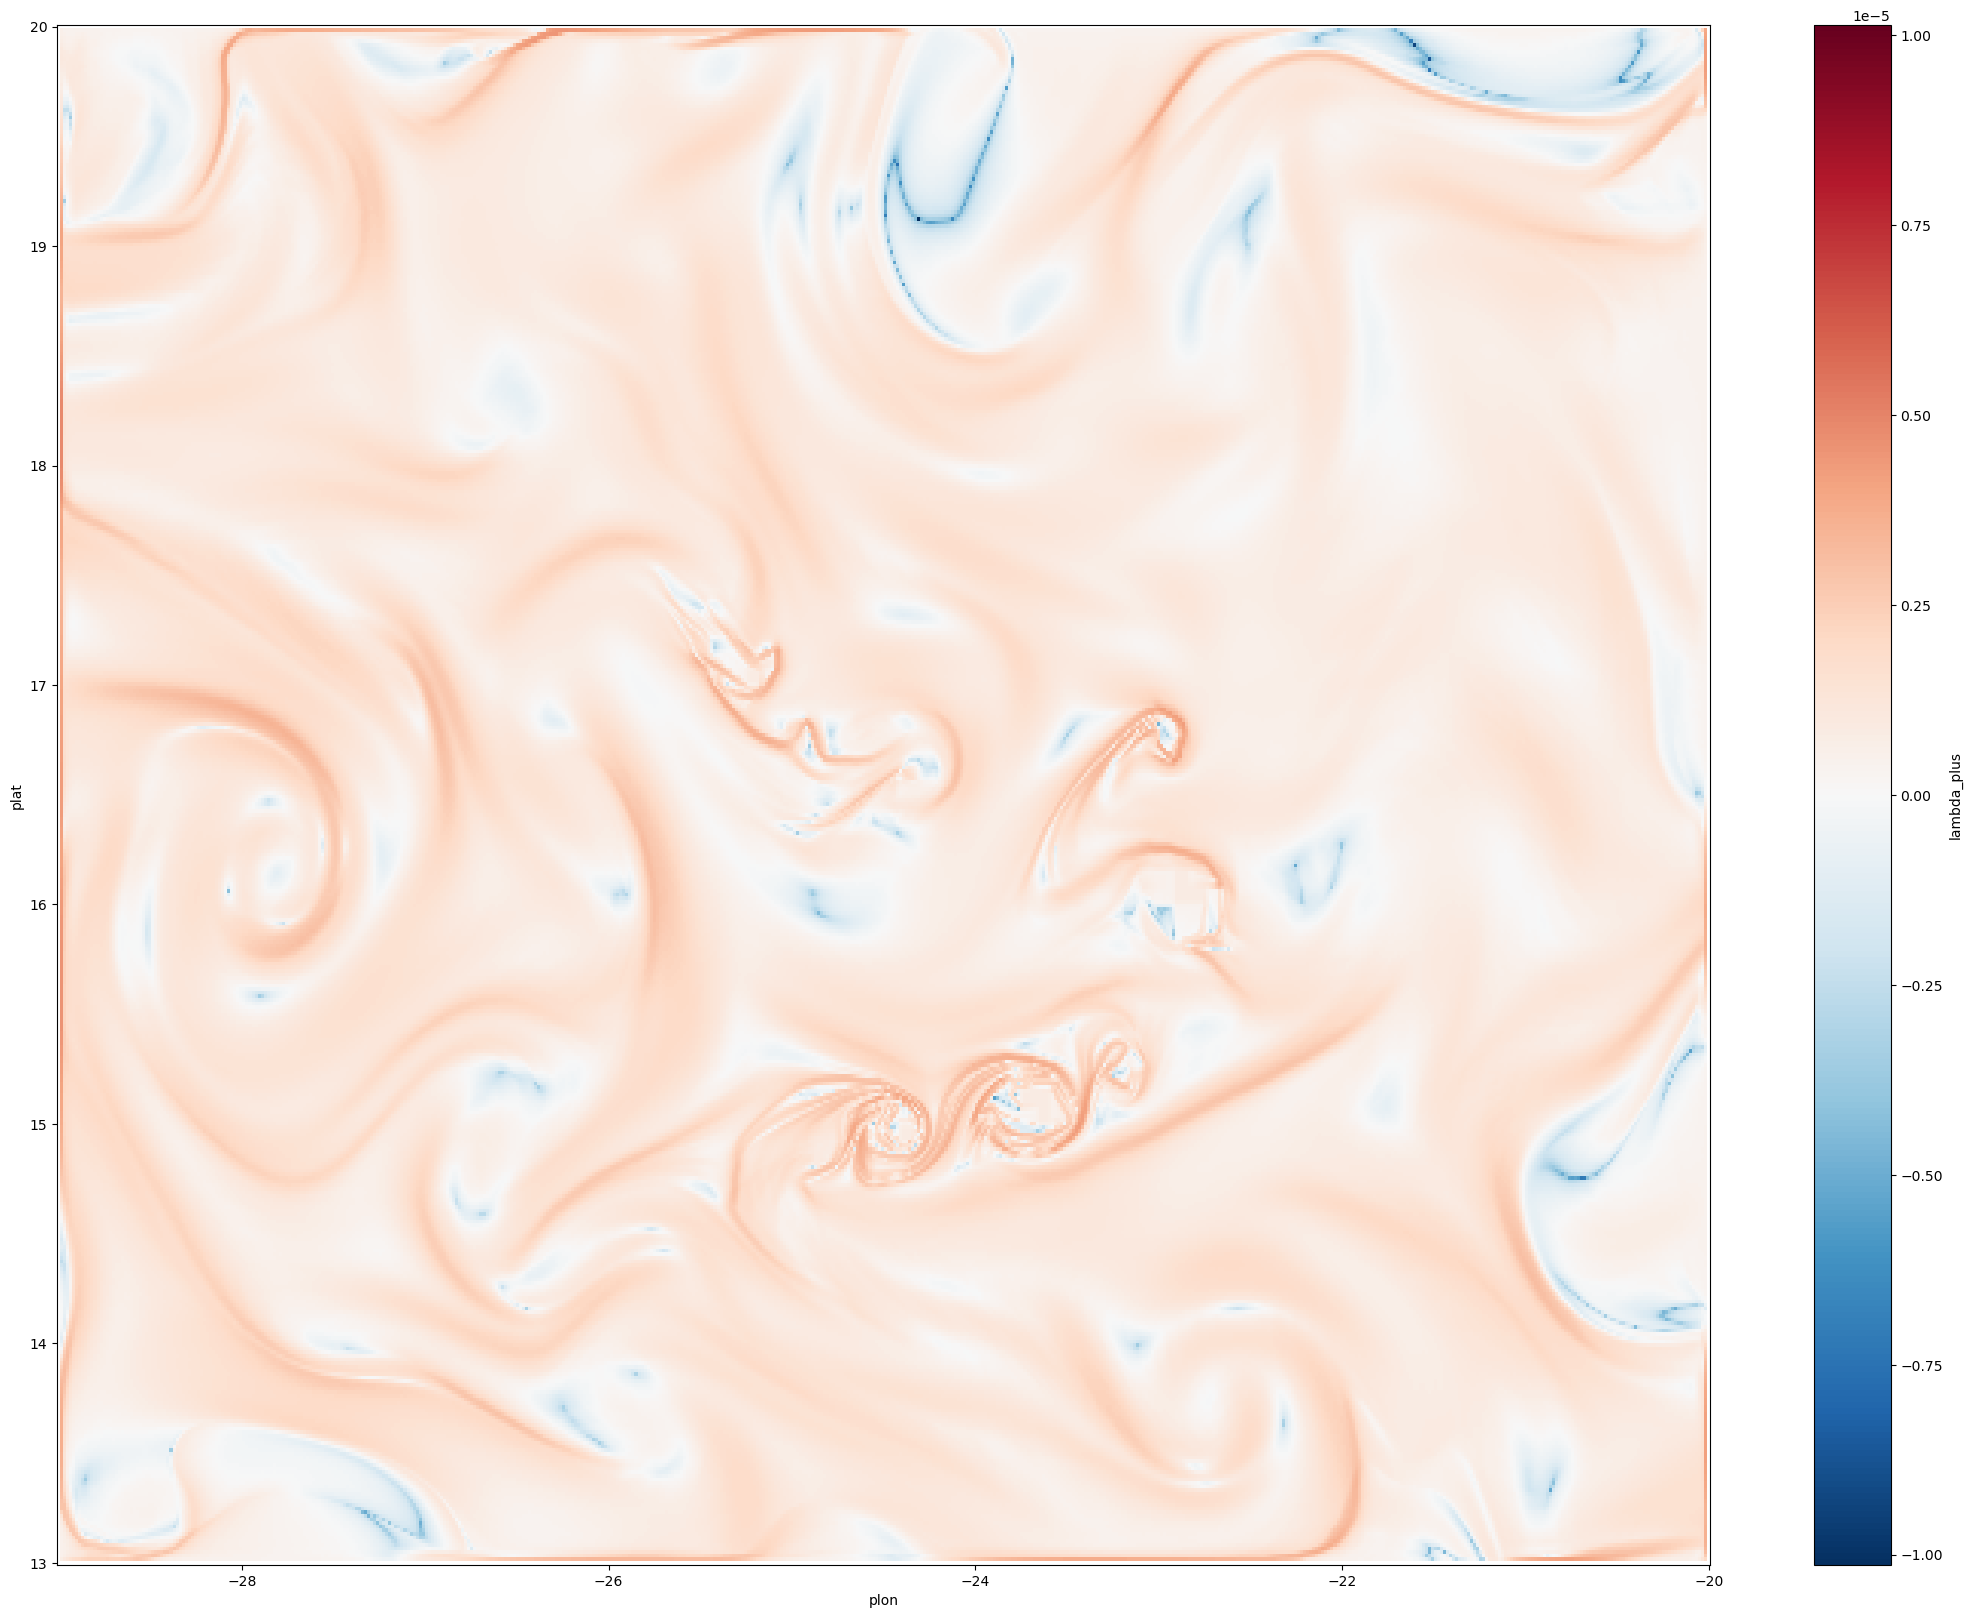

In [35]:
FTLE.plot(x="plon", y="plat", size=20)